## Data Source and Description

**Data Source:**  
National Centers for Environmental Information (NCEI)  
U.S. Department of Commerce, National Oceanic & Atmospheric Administration (NOAA)  
National Environmental Satellite, Data, and Information Service  
151 Patton Avenue, Asheville, North Carolina 28801  

**Station:** Raleigh–Durham International Airport, NC, USA  
**GHCN ID:** USW00013722 **ICAO:** KRDU  
**Location:** Latitude 35.8923° N, Longitude 78.7819° W **Elevation:** 416 ft  

**Dataset:** Local Climatological Data (LCD) Version 2  
Includes hourly and daily summaries of meteorological variables such as temperature, dew point, humidity, wind speed/direction, visibility, and atmospheric pressure.  
Data used here covers **January 2024–September 2025**, generated on **October, 2025**.  

**Access link:**  
[NOAA Local Climatological Data v2 – Raleigh Station]( https://www.ncei.noaa.gov/access/search/data-search/local-climatological-data-v2?stations=USW00013722&pageNum=1&startDate=2025-01-01T00:00:00&endDate=2025-01-01T23:59:59 )


In [1806]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

df=pd.read_csv("clean_data/updt_clean_wthr_dt.csv")
df["ds"] = pd.to_datetime(df["ds"])
df["HourlyDryBulbTemperature"]=df["Hourly_Dry_Bulb_Temp_F"]
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15173 entries, 0 to 15172
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ds                         15173 non-null  datetime64[ns]
 1   HourlyAltimeterSetting     15173 non-null  float64       
 2   HourlyDewPointTemperature  15173 non-null  float64       
 3   HourlyPrecipitation        15173 non-null  float64       
 4   HourlyRelativeHumidity     15173 non-null  float64       
 5   HourlySeaLevelPressure     15173 non-null  float64       
 6   HourlyStationPressure      15173 non-null  float64       
 7   HourlyVisibility           15173 non-null  float64       
 8   HourlyWetBulbTemperature   15173 non-null  float64       
 9   HourlyWindDirection        15173 non-null  float64       
 10  HourlyWindSpeed            15173 non-null  float64       
 11  Hourly_Dry_Bulb_Temp_F     15173 non-null  float64       
 12  year

The dataset includes hourly meteorological readings such as temperature, dew point, humidity, wind speed, visibility, and pressure. After initial inspection, missing values were removed, and all timestamps were converted to consistent datetime format in the data cleaning notebook and the final csv has been imported here. The data spans approximately 21 months, providing sufficient temporal coverage for modeling both daily and seasonal temperature cycles.


In [1807]:

df = df.sort_values("ds").reset_index(drop=True)
df["time_index"] = np.arange(len(df))


### Feature engineering 

was essential to capture the temporal structure of weather data — including long-term trends, periodic (seasonal) behavior, and short-term autocorrelation effects — using both domain knowledge and time-series concepts learned in class.

Trend: added a numerical `time_index` that increases sequentially with each hourly observation.

Seasonality : sine/cosine transformations to encode the periodic patterns in Temperatures having daily (24h) and annual (365d) cycles.


In [1808]:
# Daily (24-hour cycle)
df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24)

# Annual (12-month or 365-day cycle)
df["day_of_year"] = df["ds"].dt.dayofyear
df["sin_year"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["cos_year"] = np.cos(2 * np.pi * df["day_of_year"] / 365)


### Lag Analysis and Autocorrelation

examined autocorrelation using the acf (auto-correlation function) plot to understand how past temperatures relate to future ones checking which have most meaningful time lags that can be included as features.


<Figure size 1000x400 with 0 Axes>

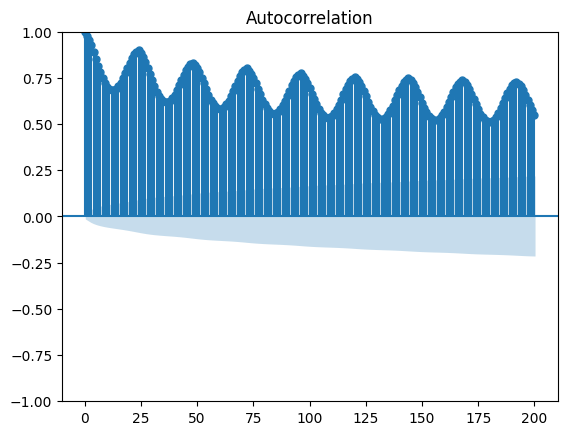

In [1809]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(df["Hourly_Dry_Bulb_Temp_F"].dropna(), lags=200)
plt.show()


#### Correlation matrix 
Heatmap to identify which features are most strongly correlated with the target

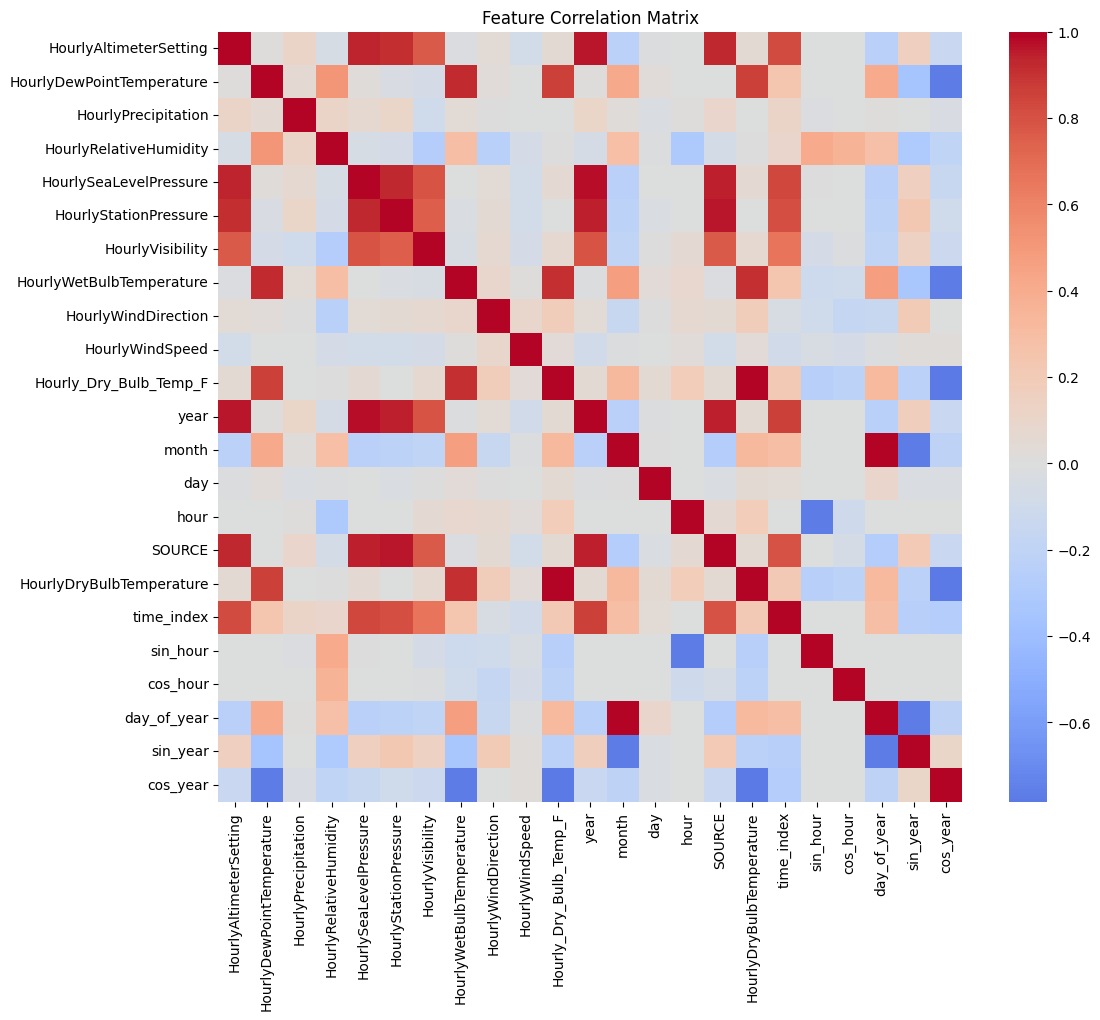

In [1810]:
import seaborn as sns

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Focus on correlations with the target (HourlyDryBulbTemperature)
target_corr = corr["HourlyDryBulbTemperature"].sort_values(ascending=False)

# Optional: visualize full correlation matrix heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Matrix")
plt.show()


### Feature Engineering and Target Definition

Several additional predictors/features added to better represent temporal and physical relationships in the weather data:

- **Lag features:** previous temperature readings (1h, 3h, 6h, 12h, 24h, 168h) to capture autocorrelation  
- **Rolling mean features:** short- to long-term moving averages (1–168h) to smooth recent fluctuations and capture gradual warming or cooling trends.
- **Interaction features:** products of related variables like sin and cosine with the lags to allow the model to adjust for time-of-day and seasonal effects.
- **Day-over-day temperature change:** difference between short- and long-term lags captures daily variation intensity.
- **Temperature Curvature (2nd Derivative):** measures acceleration or deceleration in temperature changes, often preceding peaks.
- **Recent Volatility:** rolling standard deviations over 6h and 12h windows quantify short-term instability or sudden variability.

missing values introduced by lagging were dropped.  
The target variable (`y`) is defined as `HourlyDryBulbTemperature`.

In [1811]:

# Adding lag features
for l in [1,2, 3, 6, 12, 24, 48, 72, 168]:
    df[f"temp_lag{l}"] = df["HourlyDryBulbTemperature"].shift(l)

# Adding rolling mean features
for w in [1 , 3, 6, 12, 24, 48, 72, 168]:
    df[f"temp_roll{w}"] = df["HourlyDryBulbTemperature"].shift(1).rolling(w).mean()

# second derivative (acceleration)
df["temp_accel"] = df["HourlyDryBulbTemperature"].diff().diff().shift(1)

# Volatility features (rolling std dev)
df["temp_vol6"] = df["HourlyDryBulbTemperature"].shift(1).rolling(6).std()
df["temp_vol12"] = df["HourlyDryBulbTemperature"].shift(1).rolling(12).std()

## Adding interactions
df["temp_day_change"] = df["temp_lag1"] - df["temp_lag24"]
for l in [1, 2, 3, 6, 12, 24, 48, 72 , 168]:
    df[f"sin_hour_temp_lag{l}"] = df["sin_hour"] * df[f"temp_lag{l}"]
    df[f"cos_hour_temp_lag{l}"] = df["cos_hour"] * df[f"temp_lag{l}"]
    df[f"temp_lag{l}_sq"] = df[f"temp_lag{l}"]**2
    df[f"sin_year_temp_lag{l}"] = df["sin_year"] * df[f"temp_lag{l}"]
    df[f"cos_year_temp_lag{l}"] = df["cos_year"] * df[f"temp_lag{l}"]

# Drop NaNs and retrain
df = df.dropna().reset_index(drop=True)

# Target variable
y = df["HourlyDryBulbTemperature"]

# Select useful predictors
feature_cols = [

    # Seasonal (annual)
    "cos_year_temp_lag1","cos_year_temp_lag2","sin_year_temp_lag1",

    # Diurnal interactions
    "sin_hour_temp_lag1", "cos_hour_temp_lag1",
    "sin_hour_temp_lag2", "cos_hour_temp_lag2",
    "sin_hour_temp_lag3", "cos_hour_temp_lag3",
    "sin_hour_temp_lag6", "cos_hour_temp_lag6",
    "sin_hour_temp_lag12", "cos_hour_temp_lag12",
    "sin_hour_temp_lag24", "cos_hour_temp_lag24",

    # Temperature lags
    "temp_lag1", "temp_lag3", "temp_lag6", "temp_lag12", "temp_lag24", "temp_lag48", "temp_lag72",
    "temp_lag1_sq", "temp_lag3_sq", "temp_lag6_sq", "temp_lag12_sq", "temp_lag24_sq",

    # Rolling averages
    "temp_roll1","temp_roll3", "temp_roll6", "temp_roll12", "temp_roll24", "temp_roll72",

    # Volatility features
    "temp_vol6", "temp_vol12", 

    # Additional interaction
    "temp_day_change","temp_accel",
]

X = df[feature_cols]


### Train–Test Split and Feature Scaling

To evaluate the model fairly, we split the data chronologically:
- 80% of the earliest data for training  
- 20% of the most recent data for testing  
  
All features are then standardized using `StandardScaler` to improve model stability.

In [1812]:
# split = int(len(df) * 0.80)  # 80% of data length

# # Training = first 80%, Testing = last 20%
# X_train, X_test = X.iloc[:split], X.iloc[split:]
# y_train, y_test = y.iloc[:split], y.iloc[split:]

# # Train-test split (with masking for dates)
# train_mask = df["ds"] < "2025-09-17"
# test_mask  = (df["ds"] >= "2025-09-17") & (df["ds"] <= "2025-09-30")

# X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, "HourlyDryBulbTemperature"]
# X_test,  y_test  = df.loc[test_mask,  feature_cols], df.loc[test_mask,  "HourlyDryBulbTemperature"]

# Train-test split (with masking for dates)
train_mask = df["ds"] < "2025-03-16"
test_mask  = (df["ds"] >= "2025-03-16") & (df["ds"] <= "2025-09-16")

X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, "HourlyDryBulbTemperature"]
X_test,  y_test  = df.loc[test_mask,  feature_cols], df.loc[test_mask,  "HourlyDryBulbTemperature"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled  = scaler.transform(X_test)   

# print(X_train.tail())


### Time-Series fold Cross-Validation for linear regression to check consistency over folds

To check model consistency, we used TimeSeriesSplit (3 folds) on the training data.  
Unlike random K-fold CV, this preserves temporal order, validating the model on progressively later subsets of time mimicing real-world forecasting and preventing data leakage.


In [1813]:
tscv = TimeSeriesSplit(n_splits=5)
fold = 0

print("TimeSeries Cross-Validation (on training set):")
for train_idx, val_idx in tscv.split(X_train):
    fold += 1
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LinearRegression(fit_intercept=True)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    r2   = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    print(f"Fold {fold}: R²={r2:.3f}, RMSE={rmse:.3f}")


TimeSeries Cross-Validation (on training set):
Fold 1: R²=0.935, RMSE=2.857
Fold 2: R²=0.896, RMSE=2.567
Fold 3: R²=0.958, RMSE=2.072
Fold 4: R²=0.949, RMSE=2.848
Fold 5: R²=0.939, RMSE=3.214


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

## Model Training and Prediction

We fit a **Linear Regression** model using the training set and predict hourly temperatures for the testing period.  
This is a baseline model.


In [1814]:

model = LinearRegression(fit_intercept=True)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### Feature Importance:

Determining the top 15 features of importance


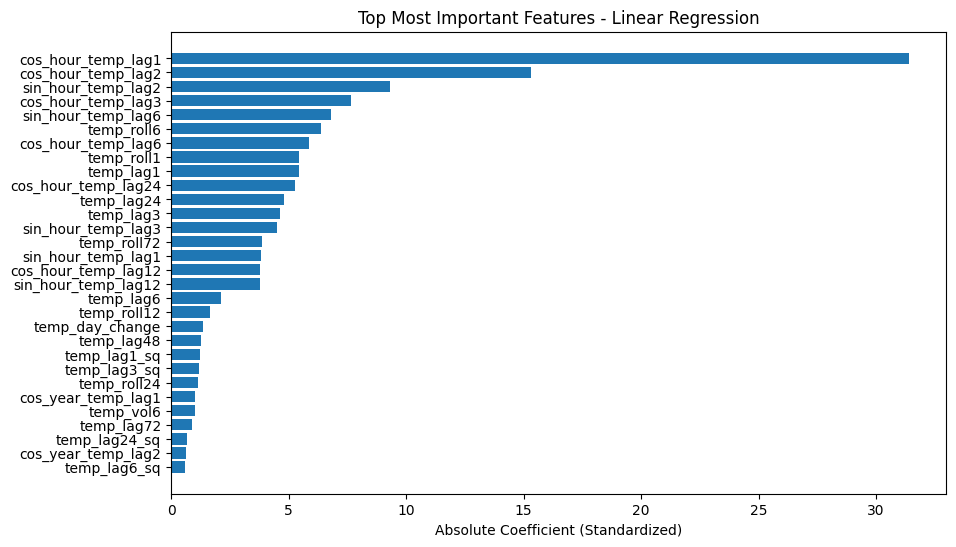

In [1815]:
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
coefs['Abs_Coefficient'] = np.abs(coefs['Coefficient'])
coefs = coefs.sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coefs['Feature'][:30][::-1], coefs['Abs_Coefficient'][:30][::-1])
plt.xlabel("Absolute Coefficient (Standardized)")
plt.title("Top Most Important Features - Linear Regression")
plt.show()

### Model Evaluation

Model performance evaluated using these metrics:

- **R² (Coefficient of Determination)** — proportion of variance explained  
- **MSE (Mean Squared Error)** — average squared prediction error  
- **RMSE (Root Mean Squared Error)** — interpretable as average prediction error in °F


In [1816]:

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R²: {r2:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")


R²: 0.954
MSE: 5.287
RMSE: 2.299


### Visualizations

Plotted the **actual vs. predicted temperatures** over the test period.
Deviations highlight times when linear assumptions havent fully capture non-linear weather dynamics. We see a consistent bias in the model which captures the over trend and seasonality well but struggles to manage the range of the temperatures.


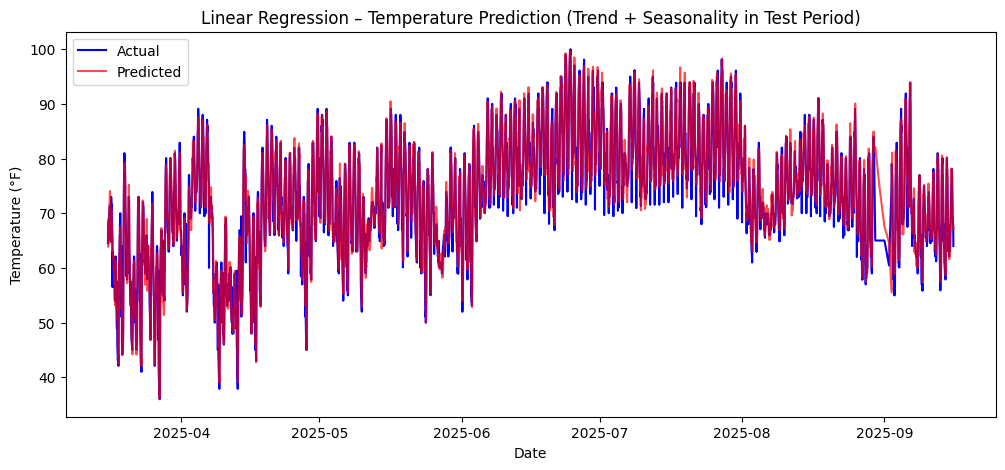

In [1817]:
plt.figure(figsize=(12,5))
plt.plot(df.loc[test_mask, "ds"], y_test, label="Actual", color="blue")
plt.plot(df.loc[test_mask, "ds"], y_pred, label="Predicted", color="red", alpha=0.7)
plt.legend()
plt.title("Linear Regression – Temperature Prediction (Trend + Seasonality in Test Period)")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.show()


### Forecasted values

For the timeperiod September 17 to 30 ,2025.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


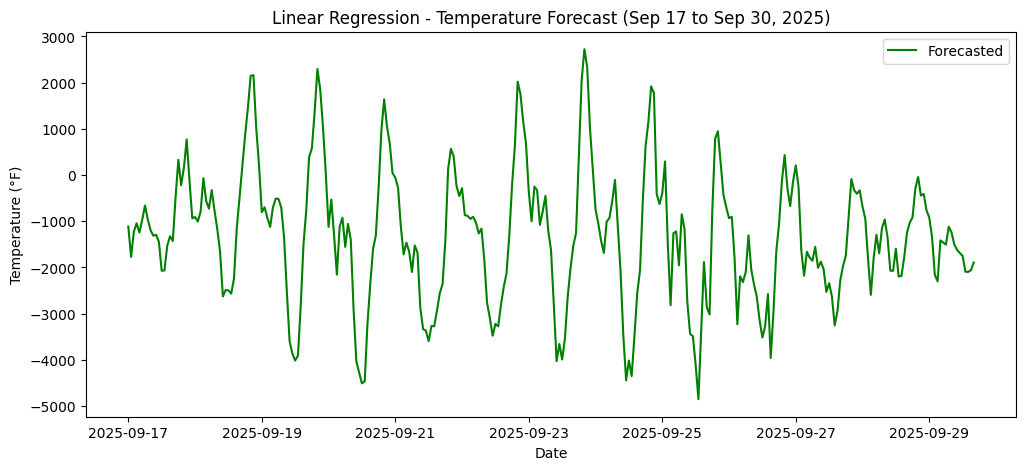

In [1818]:
forecast_mask  = (df["ds"] >= "2025-09-17") & (df["ds"] <= "2025-09-30")
y_forecast = model.predict(X.loc[forecast_mask])
plt.figure(figsize=(12,5))
plt.plot(df["ds"].loc[forecast_mask], y_forecast, label="Forecasted", color="green")
plt.legend()
plt.title("Linear Regression - Temperature Forecast (Sep 17 to Sep 30, 2025)")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.show()

### Limitations

The model successfully captures temperature trends and seasonality using linear regression with engineered features.  
However, performance could be improved by using Nonlinear models or other categorical features.

Linear regression provides interpretability, but may not fully capture sudden weather transitions or nonlinear interactions.
